# Markov Chain Monte Carlo

Author: Fred J. Hickernell + ChatGPT

#### Some LaTeX macros (hidden in math mode, will not render correctly in VS Code)
$
\newcommand{\vh}{\boldsymbol{h}}
\newcommand{\vt}{\boldsymbol{t}}
\newcommand{\vx}{\boldsymbol{x}}
\newcommand{\vX}{\boldsymbol{X}}
\newcommand{\vU}{\boldsymbol{U}}
\newcommand{\vzero}{\boldsymbol{0}}
\newcommand{\cf}{\mathcal{F}}
\newcommand{\cn}{\mathcal{N}}
\newcommand{\cu}{\mathcal{U}}
\newcommand{\cgp}{\mathcal{G}\!\mathcal{P}}
\newcommand{\dif}{\mathrm{d}}
\newcommand{\Ex}{\mathbb{E}}
\newcommand{\Prob}{\mathbb{P}}
\newcommand{\bbone}{\mathbb{1}}
\newcommand{\disc}{\operatorname{disc}}
\newcommand{\norm}[2]{{\left \lVert #1 \right \rVert}_{#2}}
$

#### Run this notebook in Juypter with the `conda qmcpy` environment or [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/MATH565Fall2025/blob/main/notebooks/GeneratingRandomVectors.ipynb?flush_cache=true)

In [4]:
if "google.colab" in str(get_ipython()):
    print("⚡Note: Setup here can take a few minutes.")
    !apt-get -y install cm-super dvipng texlive-latex-extra texlive-latex-recommended
    !pip install git+https://github.com/QMCSoftware/QMCSoftware.git@develop
    !git clone https://github.com/QMCSoftware/MATH565Fall2025.git
    %cd MATH565Fall2025/notebooks
    print("\n✅ Colab setup complete.")
    print("   For faster performance, please install the qmcpy environment locally.")

### Import needed packages and initialize some parameters

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import qmcpy as qp
from IPython.display import display, Markdown
import nbviz as nb
nb.init(use_tex=True)                     # styling, Tol cycle, CSS, interactive plotting
colors = nb.TOL_BRIGHT                    # e.g., colors["cyan"]
TINY = nb.TINY

## Recalling Acceptance Rejection Sampling
To sample from complicated target (unnormalized) probability densities, one can sample from a suitable proposal density and then either accept or reject the samples.

At a high level, there is a
- a target (unnormalized) PDF, $\varrho$
- a proposal PDF, $\varrho_Z$
- a constant $M$ such that $\varrho(z) \le M \varrho_Z(z)$
A sample, $Z\sim \varrho_Z$ and $U \sim \mathcal{U}[0,1]$, yields a new sample from the target distribution if
$$
U \le \varrho(Z)/[M\varrho_Z(Z)] \qquad \textsf{or equivalently} \qquad \log(U) + \log(M) + \log(\varrho_Z(Z)) - \log(\varrho(Z)) \le 0
$$

Here is code for a general acceptance-rejection sampler. We need to supply logarithms of the target and proposal densities because logarithms are more numerically stable.

In [24]:
def accept_reject(
    log_target_density,        # log of unnormalized target density, takes array (n,d) → array (n,)
    proposal_sampler,          # proposal sampler, proposal_sampler(n, rng) → array (n,d)
    log_prop_density=None,     # log proposal density, same vectorization as log_target_density. Optional.
    M=None,                    # constant ≥ sup_x target_density(x)/q(x). Required if log_prop_density is given.
    n_samples=1000,            # number of samples requested
    pilot_n=100,               # number of pilot samples to estimate acceptance rate
    batch_max=50000,           # maximum batch size, do not want to run out of memory
    max_proposals=None,        # maxmum number of proposals
    rng=None
):
    """
    Generic accept–reject sampling with batch sizing based on a pilot run.

    Modes:
    1) General AR (log_prop_density and M provided):
         Accept with prob = exp(log_target_density(x) - log_prop_density(x)) / M.
    2) Unit-peak mode (log_prop_density=None, M=None):
         Assumes 0 <= exp(log_target_density(x)) <= 1 and proposal is uniform on its support.
         Accept with prob = exp(log_target_density(x)).
    """
    rng = np.random.default_rng(rng)

    unit_peak_mode = (log_prop_density is None)
    if unit_peak_mode:
        if M is not None:
            raise ValueError("Do not provide M in unit-peak mode.")
        mode = "unit-peak"
    else:
        if M is None or M <= 0:
            raise ValueError("Must provide positive M in general AR mode.")
        mode = "general"

    accepted = []
    proposed_total = 0
    batches = 0

    def propose_and_accept(n_prop):
        """Draw proposals and apply accept–reject test."""
        x = proposal_sampler(n_prop, rng)   # shape (n_prop, d)
        if x.ndim != 2:
            raise ValueError("proposal_sampler must return a 2D array of shape (n, d).")

        lp = log_target_density(x)

        if unit_peak_mode:
            # acceptance prob = exp(log_target_density(x)), assumed in [0,1]
            a = np.exp(np.minimum(lp, 0.0))
        else:
            lq = log_prop_density(x)
            a = np.exp(lp - lq) / M
            a = np.minimum(a, 1.0)

        # Safety: zero-out non-finite probabilities
        a = np.where(np.isfinite(a) & (a >= 0), a, 0.0)

        u = rng.random(size=n_prop)
        acc = (u < a)
        return x, acc

    # --- Pilot run ---
    x_pilot, acc_pilot = propose_and_accept(pilot_n)
    pilot_acc_rate = float(acc_pilot.mean()) if pilot_n > 0 else 0.0
    accepted.append(x_pilot[acc_pilot])
    proposed_total += pilot_n
    batches += 1

    # Early exit if pilot already gave enough
    have = sum(chunk.shape[0] for chunk in accepted)
    if have >= n_samples:
        out = np.concatenate(accepted, axis=0)[:n_samples]
        info = dict(
            proposed=proposed_total,
            accepted=n_samples,
            pilot_accept_rate=pilot_acc_rate,
            final_accept_rate=n_samples / proposed_total,
            batches=batches,
            mode=mode,
            M=(None if unit_peak_mode else float(M)),
        )
        return out, info

    remaining = n_samples - have
    use_estimate = pilot_acc_rate > 0

    # --- Main loop ---
    while remaining > 0:
        if use_estimate:
            # overshoot by 10% for safety
            n_prop = int(np.ceil(1.10 * remaining / pilot_acc_rate))
        else:
            n_prop = batch_max

        n_prop = min(n_prop, batch_max)
        if (max_proposals is not None) and (proposed_total + n_prop > max_proposals):
            n_prop = max(0, max_proposals - proposed_total)
            if n_prop == 0:
                break

        x_batch, acc_batch = propose_and_accept(n_prop)
        accepted.append(x_batch[acc_batch])
        proposed_total += n_prop
        batches += 1
        remaining = n_samples - sum(chunk.shape[0] for chunk in accepted)

    got = sum(chunk.shape[0] for chunk in accepted)
    if got == 0:
        raise RuntimeError(
            "No samples were accepted. In general AR mode, check that your bound constant M is large enough. "
            "In unit-peak mode, check that your unnormalized density is between 0 and 1."
        )

    samples = np.concatenate(accepted, axis=0)
    if samples.shape[0] >= n_samples:
        samples = samples[:n_samples]

    info = dict(
        proposed=proposed_total,
        accepted=samples.shape[0],
        pilot_accept_rate=pilot_acc_rate,
        final_accept_rate=samples.shape[0] / proposed_total if proposed_total > 0 else 0.0,
        batches=batches,
        mode=mode,
        M=(None if unit_peak_mode else float(M)),
    )
    return samples, info

### A banana shaped unnormalized density
The following is an example of a nontrivial densit for which it would be difficult to use a quantile function to generate random samples

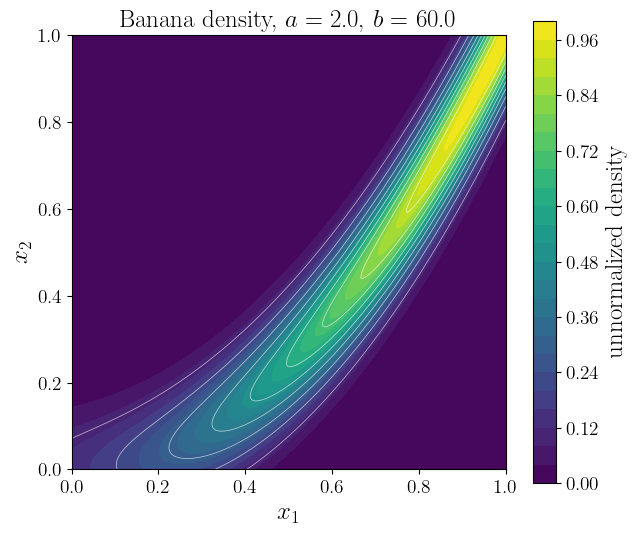

In [25]:
def log_banana(points, a=2.0, b=60.0):  # Example of a banana shaped target on [0,1]^2
    x, y = points[:,0], points[:,1]
    inside = (x>=0)&(x<=1)&(y>=0)&(y<=1)
    output = np.full(points.shape[0], -np.inf)
    output[inside] = -a*(1-x[inside])**2 - b*(y[inside]-x[inside]**2)**2
    return output

#Plot the banana
a = 2.
b = 60.
def plot_banana(a=a, b=b, n_grid=200):
    xs = np.linspace(0, 1, n_grid)
    ys = np.linspace(0, 1, n_grid)
    X, Y = np.meshgrid(xs, xs)
    pts = np.column_stack([X.ravel(), Y.ravel()])
    Z = np.exp(log_banana(pts, a=a, b=b)).reshape(X.shape)  #take the exponential of the log banana
    fig, ax = plt.subplots(figsize=(7,6))
    cf = ax.contourf(X, Y, Z, levels=30, cmap="viridis")
    cs = ax.contour(X, Y, Z, levels=10, colors="white", linewidths=0.5, alpha=0.7)
    ax.set_aspect('equal')
    fig.colorbar(cf, ax=ax, label="unnormalized density")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_title(f"Banana density, $a=$ {a}, $b=$ {b}")
    return ax

plot_banana(a=a, b=b);

{'proposed': 86210, 'accepted': 10000, 'pilot_accept_rate': 0.11, 'final_accept_rate': 0.11599582415033059, 'batches': 3, 'mode': 'unit-peak', 'M': None}


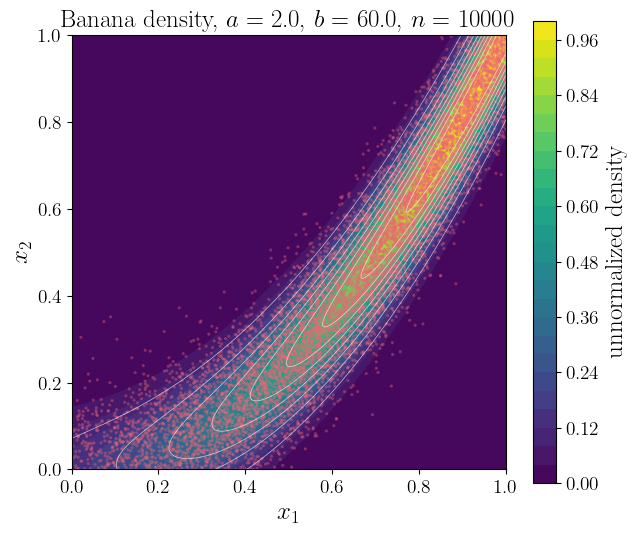

In [26]:
def sampler_uniform_01(d, n, rng=None):  #the uniform sampler to 
    rng = np.random.default_rng(rng)
    return rng.random((n,d))   # uniform on [0,1]^2

#Run the acceptance-rejection sampler
#Note that the uniform density proposal always lies above the target
n = 10_000
samples, info = accept_reject(
    log_target_density = lambda z: log_banana(z, a=a, b=b),
    proposal_sampler = lambda n, rng: sampler_uniform_01(2,n),
    log_prop_density = None,
    M = None,
    n_samples = n
)

print(info)
marker_size = 5
ax = plot_banana(a=a, b=b)
ax.scatter(samples[:,0], samples[:,1], s=marker_size, c=colors["red"], alpha=0.4, edgecolor="none")
ax.set_title(f"Banana density, $a=$ {a}, $b=$ {b}, $n=$ {n}");


## Markov Chain Monte Carlo (MCMC)

The weakness in acceptance-rejection sampling is that it samples from just one one proposal distribution.  Markov chain Monte Carlo overcomes this weakness by moving from positions of low density to those of higher densitiy.  Next we introduce the Metropolis-Hastings version of MCMC and contrast it with acceptance-rejection sampling.

Suppose that
* You really want to sample $\boldsymbol{X}$ with known (unnormalized) target density $\varrho$
* You have a proposal density $\varrho_{\text{new} | \text{old}}$ to select the next point starting from where you are
  
Metropolis-Hastings sampling proceeds as follows
$$
\begin{array}{l}
\text{Given } x_0 \\
\text{For } i = 0 \text{ to } n-1 \\
\begin{array}{lrl}
& \text{Generate } & z \sim \varrho_{\text{new} | \text{old}}(\cdot | x_i) \\
&& U \sim \mathcal{U}[0,1] \\
& \text{If } &U \le \min \left(1, \frac{\varrho(z) \varrho_{\text{new} | \text{old}}( x_i | z)}{\varrho(x_i) \varrho_{\text{new} | \text{old}}(z | x_i)}  \right) \\
&& x_{i+1} = z \\
& \text{Else} \\
&& x_{i+1} = x_i
\end{array}
\end{array}
$$

If $\varrho_{\text{new} | \text{old}}( x | z)= \varrho_{\text{new} | \text{old}}(z | x)$. then the decision criterion simplifies and this is called the Metropolis algorithm

In [27]:
def metropolis(log_target_density, x0, n_samples=50_000, proposal_sd=0.15, rng=None):
    """
    Random-walk Metropolis with Normal(0, proposal_sd^2 I) proposals.
    Returns samples (n_samples, d) and acceptance rate.
    """
    rng = np.random.default_rng(rng)
    x = np.array(x0, dtype=float)
    d = x.size
    samples = np.empty((n_samples, d))
    log_fx = log_target_density(x)
    accepts = 0

    for i in range(n_samples):
        z = x + rng.normal(scale=proposal_sd, size=d)
        log_fz = log_target_density(z)
        if np.log(rng.uniform()) < (log_fz - log_fx):
            x, log_fx = z, log_fz
            accepts += 1
        samples[i] = x

    return samples, accepts / n_samples

0.7061


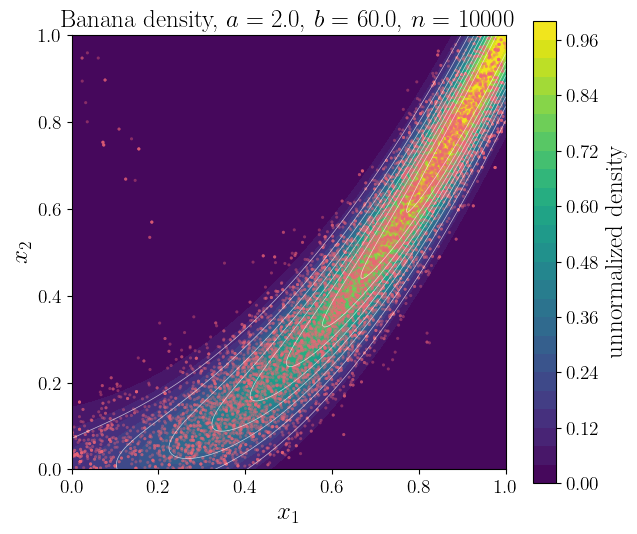

In [32]:
n = 10_000
x0 = np.array([[0,1]])
met_samples, acc = metropolis(log_target_density = lambda z: log_banana(z, a=a, b=b),
                     x0=x0, n_samples=n, proposal_sd=0.05)
print(acc)
marker_size = 5
ax = plot_banana(a=a, b=b)
ax.scatter(met_samples[:,0], met_samples[:,1], s=marker_size, c=colors["red"], alpha=0.4, edgecolor="none")
ax.set_title(f"Banana density, $a=$ {a}, $b=$ {b}, $n=$ {n}");